In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
df=pd.read_csv("clean_data.csv")
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Month,DayName
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12,Tuesday


# Phase 5 – RFM (Recency, Frequency, Monetary) Analysis

## Objective

The objective of this phase is to segment customers based on their purchasing behavior using the RFM framework.

RFM analysis helps businesses identify:

- Champions
- Loyal Customers
- Potential Loyalists
- At Risk Customers
- Lost Customers

These customer segments enable businesses to design targeted marketing campaigns, improve customer retention, and maximize customer lifetime value.

## What is RFM?

RFM is a customer segmentation technique based on three key behavioral metrics.

### Recency (R)

How recently has the customer made a purchase?

Customers who purchased recently are more likely to purchase again.

---

### Frequency (F)

How often has the customer purchased?

Customers who purchase frequently are generally more loyal.

---

### Monetary (M)

How much money has the customer spent?

Customers with higher spending contribute more revenue and usually deserve greater retention efforts.

In [4]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [5]:
analysis_date=df["InvoiceDate"].max()+pd.Timedelta(days=1)
print("Analysis Date: ",analysis_date)

Analysis Date:  2011-12-10 12:50:00


## Why do we define an Analysis Date?

Recency measures the number of days since a customer's most recent purchase.

To calculate this consistently for every customer, a single reference date (Analysis Date) is selected.

The analysis date is defined as one day after the latest transaction in the dataset.

This ensures that every customer's recency is measured relative to the same point in time.

In [6]:
rfm=df.groupby("Customer ID").agg({
    "InvoiceDate":"max",
    "Invoice":"nunique",
    "TotalPrice":"sum"
})
rfm.head()

,InvoiceDate,Invoice,TotalPrice
Customer ID,,,
12346.0,2011-01-18 10:01:00,12,77556.46
12347.0,2011-12-07 15:52:00,8,4921.53
12348.0,2011-09-25 13:13:00,5,2019.40
12349.0,2011-11-21 09:51:00,4,4428.69
12350.0,2011-02-02 16:01:00,1,334.40


In [7]:
rfm_final=rfm.copy()

In [8]:
rfm_final.rename(columns={
    "InvoiceDate":"Recency",
    "Invoice":"Frequency",
    "TotalPrice":"Monetary"
}, inplace=True)
rfm_final.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,2011-01-18 10:01:00,12,77556.46
12347.0,2011-12-07 15:52:00,8,4921.53
12348.0,2011-09-25 13:13:00,5,2019.40
12349.0,2011-11-21 09:51:00,4,4428.69
12350.0,2011-02-02 16:01:00,1,334.40


In [9]:
rfm_final["Recency"] = (
    analysis_date - rfm_final["Recency"]
).dt.days

In [10]:
rfm_final.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [11]:
rfm_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5881 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    5881 non-null   int64  
 1   Frequency  5881 non-null   int64  
 2   Monetary   5881 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 183.8 KB


In [12]:
rfm_final.describe()

,Recency,Frequency,Monetary
count,5881.000000,5881.000000,5881.000000
mean,201.457745,6.287196,2954.396237
std,209.474135,13.012879,14437.322635
min,1.000000,1.000000,0.000000
25%,26.000000,1.000000,341.900000
50%,96.000000,3.000000,865.600000
75%,380.000000,7.000000,2247.720000
max,739.000000,398.000000,580987.040000


## RFM Table Created

Each customer is now represented by three business metrics:

- **Recency:** Number of days since the customer's last purchase.
- **Frequency:** Number of unique purchases made by the customer.
- **Monetary:** Total amount spent by the customer.

This customer-level table forms the foundation for customer segmentation in the following steps.

# RFM Scoring

## Objective

The Recency, Frequency, and Monetary values are converted into scores ranging from **1 to 5**.

This standardizes customer behavior and makes it easier to compare customers.

### Scoring Logic

- **Recency:** Lower values receive higher scores.
- **Frequency:** Higher values receive higher scores.
- **Monetary:** Higher values receive higher scores.

In [13]:
rfm_final["R"] = pd.qcut(
    rfm_final["Recency"],
    q=5,
    labels=[5,4,3,2,1]
)

In [14]:
rfm_final["F"] = pd.qcut(
    rfm_final["Frequency"].rank(method="first"),
    q=5,
    labels=[1,2,3,4,5]
)

In [15]:
rfm_final["M"] = pd.qcut(
    rfm_final["Monetary"],
    q=5,
    labels=[1,2,3,4,5]
)

In [16]:
rfm_final.head()

,Recency,Frequency,Monetary,R,F,M
Customer ID,,,,,,
12346.0,326,12,77556.46,2,5,5
12347.0,2,8,4921.53,5,4,5
12348.0,75,5,2019.40,3,4,4
12349.0,19,4,4428.69,5,3,5
12350.0,310,1,334.40,2,1,2


In [17]:
print("Recency Score Distribution")
print(rfm_final["R"].value_counts().sort_index())

print("\nFrequency Score Distribution")
print(rfm_final["F"].value_counts().sort_index())

print("\nMonetary Score Distribution")
print(rfm_final["M"].value_counts().sort_index())

Recency Score Distribution
R
5    1189
4    1176
3    1167
2    1191
1    1158
Name: count, dtype: int64

Frequency Score Distribution
F
1    1177
2    1176
3    1176
4    1176
5    1176
Name: count, dtype: int64

Monetary Score Distribution
M
1    1177
2    1176
3    1176
4    1176
5    1176
Name: count, dtype: int64


In [18]:
rfm_final["RFM_Score"] = (
    rfm_final["R"].astype(str) +
    rfm_final["F"].astype(str) +
    rfm_final["M"].astype(str)
)

In [19]:
def customer_segment(row):

    if row["R"] >= 4 and row["F"] >= 4 and row["M"] >= 4:
        return "Champions"

    elif row["R"] >= 3 and row["F"] >= 3 and row["M"] >= 3:
        return "Loyal Customers"

    elif row["R"] >= 4 and row["F"] <= 2:
        return "Potential Loyalists"

    elif row["R"] <= 2 and row["F"] >= 3:
        return "At Risk"

    elif row["R"] <= 2 and row["F"] <= 2:
        return "Lost Customers"

    else:
        return "Needs Attention"

In [20]:
rfm_final["Customer_Segment"] = rfm_final.apply(customer_segment, axis=1)

In [21]:
rfm_final.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Score,Customer_Segment
Customer ID,,,,,,,,
12346.0,326,12,77556.46,2,5,5,255,At Risk
12347.0,2,8,4921.53,5,4,5,545,Champions
12348.0,75,5,2019.40,3,4,4,344,Loyal Customers
12349.0,19,4,4428.69,5,3,5,535,Loyal Customers
12350.0,310,1,334.40,2,1,2,212,Lost Customers


In [25]:
segment_counts = (
    rfm_final["Customer_Segment"]
    .value_counts()
)

segment_counts

Customer_Segment
Lost Customers         1525
Champions              1297
Loyal Customers        1138
At Risk                 824
Needs Attention         653
Potential Loyalists     444
Name: count, dtype: int64

In [26]:
rfm_final.to_csv("rfm.csv",index=False)

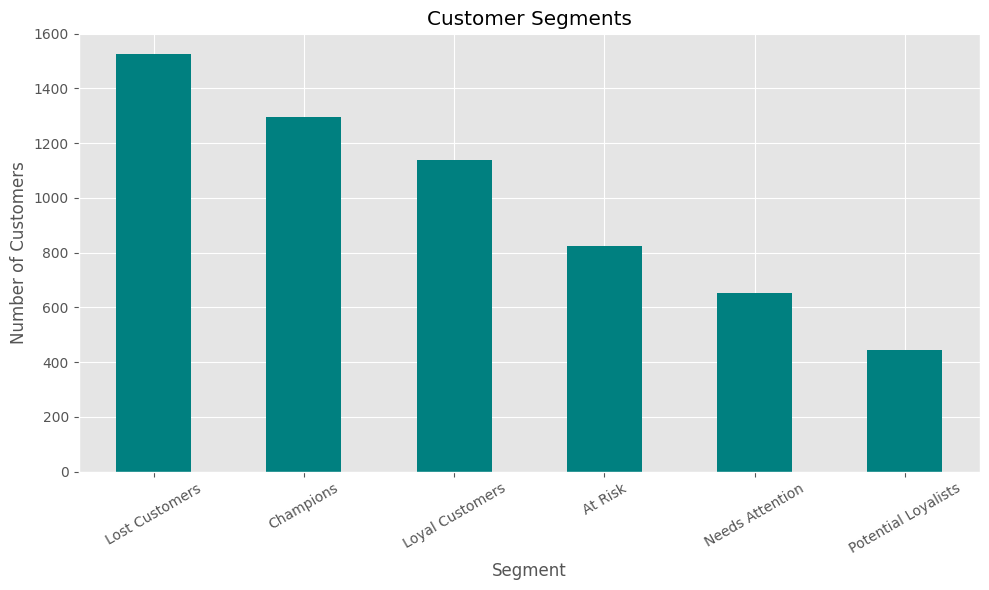

In [23]:
plt.figure(figsize=(10,6))

segment_counts.plot(
    kind="bar",
    color="teal"
)

plt.title("Customer Segments")

plt.xlabel("Segment")

plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

In [24]:
rfm.to_csv("rfm_customers.csv", index=False)

# Customer Segmentation

## Objective

Customers were segmented based on their RFM scores into meaningful business groups.

### Segments

- Champions
- Loyal Customers
- Potential Loyalists
- Needs Attention
- At Risk
- Lost Customers

These segments help businesses design personalized marketing strategies and improve customer retention.

# Business Recommendations

## Champions

Reward with exclusive offers, VIP programs, and early access to products.

## Loyal Customers

Maintain engagement through loyalty rewards and personalized communication.

## Potential Loyalists

Encourage repeat purchases using targeted promotions and product recommendations.

## Needs Attention

Monitor purchasing behavior and re-engage through reminder campaigns.

## At Risk

Launch retention campaigns before these customers become inactive.

## Lost Customers

Run win-back campaigns with attractive discounts or personalized offers to encourage reactivation.